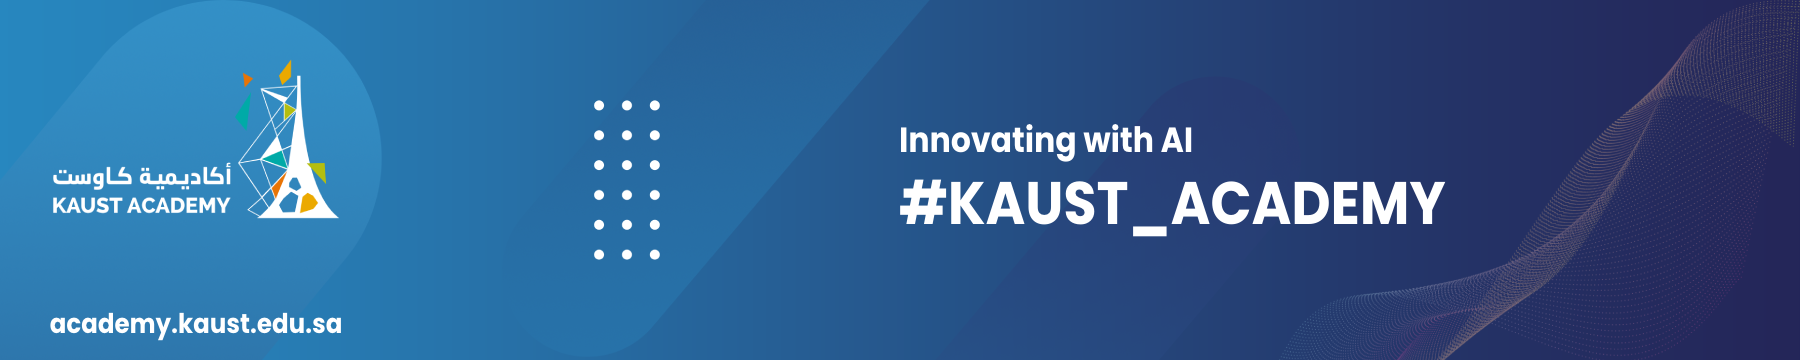

This notebook has been inspired from [Actor Critic Example](https://github.com/pytorch/examples/blob/main/reinforcement_learning/actor_critic.py) and [actor_critic](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/reinforcement_learning/actor_critic.ipynb#scrollTo=-mJ2i6jvZ3sK).

### Setup

We standardize on **Gymnasium** (with Box2D for LunarLander) plus `imageio` for GIF rendering, installed with **uv**. `torch` is the deep-learning backend.

In [ ]:
# Fast dependency install with uv (https://docs.astral.sh/uv).
# Bootstraps uv via pip, then installs into the current kernel/venv. If you already
# run from the project's .venv (created with `uv sync`), this is essentially a no-op.
# (torch ships with Colab; locally `uv sync` installs it.)
import sys, os
%pip install -q uv
_target = "" if (sys.prefix != sys.base_prefix or os.environ.get("VIRTUAL_ENV")) else "--system"
!uv pip install -q {_target} --python "{sys.executable}" swig
!uv pip install -q {_target} --python "{sys.executable}" "gymnasium[box2d]" imageio matplotlib torch

# Actor Critic

In this notebook, we will implementa basic Actor Critic Reinforcement learning algorithm for Lunar Lander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the cartpole environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![Cartpole](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Actor Critic Methods

Actor-Critic methods are [temporal difference (TD) learning](https://en.wikipedia.org/wiki/Temporal_difference_learning) methods that represent the policy function independent of the value function.

A policy function (or policy) returns a probability distribution over actions that the agent can take based on the given state.
A value function determines the expected return for an agent starting at a given state and acting according to a particular policy forever after.

In the Actor-Critic method, the policy is referred to as the *actor* that proposes a set of possible actions given a state, and the estimated value function is referred to as the *critic*, which evaluates actions taken by the *actor* based on the given policy.

In this tutorial, both the *Actor* and *Critic* will be represented using one neural network with two outputs.




### 3. The Actor-Critic loss

Since you're using a hybrid Actor-Critic model, the chosen loss function is a combination of Actor and Critic losses for training, as shown below:

$$L = L_{actor} + L_{critic}$$

#### The Actor loss

The actor is updated with the policy gradient, using the **TD residual** as a low-variance,
online estimate of the advantage (see Day 3 -> Day 4):

$$L_{actor} = -\sum_{t} \log\pi_{\theta}(a_t \mid s_t)\, \delta_t,
\qquad \delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$$

where:
- $s_t, a_t$: state and action at timestep $t$
- $\pi_{\theta}$: the policy (**actor**)
- $V_\phi$: the value function (**critic**)
- $\delta_t$: the TD residual. We **detach** it when updating the actor, so the critic is not
  pulled around by the policy gradient.

##### The Advantage (TD residual)

$\delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$ is an estimate of the
[advantage](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html#advantage-functions)
$A^{\pi}(s_t,a_t)$: how much better action $a_t$ was than the critic expected from $s_t$.

Unlike REINFORCE-with-a-baseline (Day 3), which used the full Monte-Carlo return $G_t - V(s_t)$,
the TD residual **bootstraps** off $V_\phi(s_{t+1})$ instead of waiting for the whole episode.
That is what makes it lower-variance and usable at every step. $\delta_t > 0$ pushes the action's
probability up; $\delta_t < 0$ pushes it down.

#### The Critic loss

The critic is regressed toward its own TD target $r_t + \gamma V_\phi(s_{t+1})$ (treated as a
constant) with the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss):

$$L_{critic} = L_{\delta}\big(V_\phi(s_t),\; r_t + \gamma V_\phi(s_{t+1})\big)$$

Minimising this drives the TD residual toward zero, i.e. makes $V_\phi$ a better value estimate.

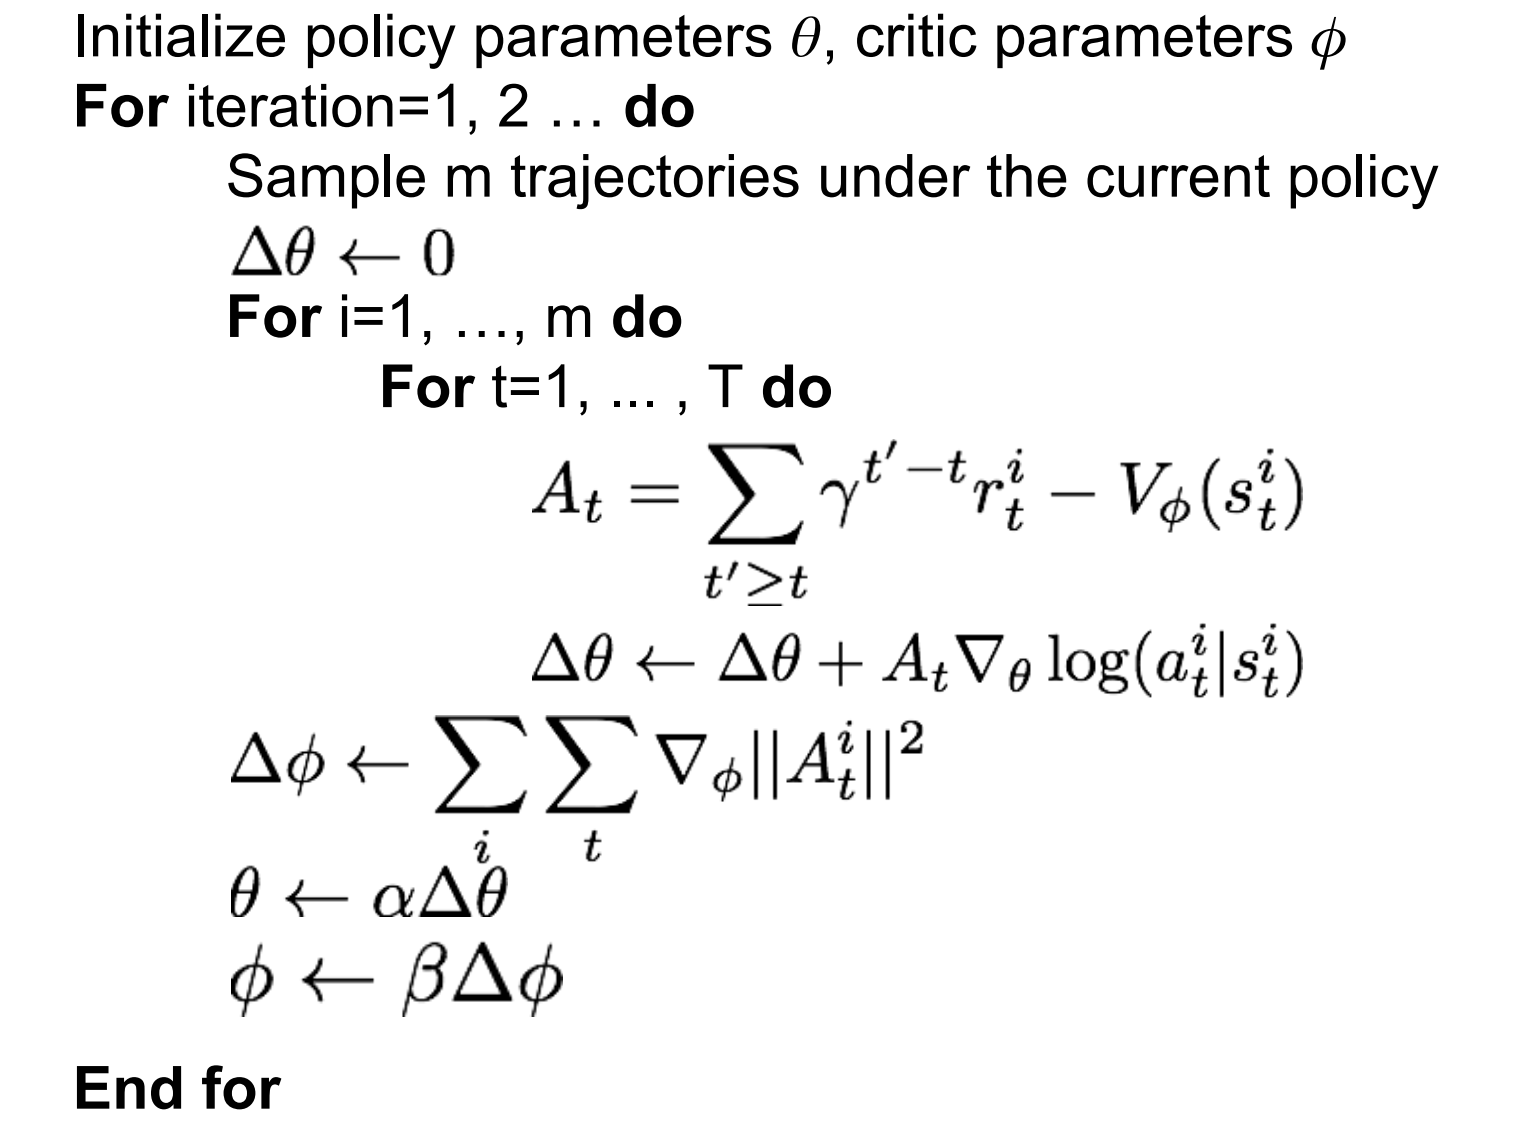

[Image Source](http://cs231n.stanford.edu/slides/2017/cs231n_2017_lecture14.pdf)

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

In [ ]:
# Create the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")

### Actor Critic Network

In [ ]:
class ActorCritic(nn.Module):
    """Shared-body actor-critic: one network with a policy head and a value head."""
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.affine1 = nn.Linear(n_observations, 128)
        self.action_head = nn.Linear(128, n_actions)   # actor: action logits
        self.value_head = nn.Linear(128, 1)            # critic: state value V(s)

    def forward(self, x):
        x = F.relu(self.affine1(x))
        action_prob = F.softmax(self.action_head(x), dim=-1)
        state_value = self.value_head(x)
        return action_prob, state_value

    def act(self, state):
        """Sample an action from the policy (used while collecting experience)."""
        state = torch.from_numpy(np.asarray(state)).float().unsqueeze(0).to(device)
        with torch.no_grad():
            probs, _ = self.forward(state)
        return Categorical(probs).sample().item()

    def evaluate(self, states, actions):
        """Re-run the network on a batch of states to get, with gradients:
        log pi(a|s), V(s), and the policy entropy."""
        probs, values = self.forward(states)
        m = Categorical(probs)
        return m.log_prob(actions), values.squeeze(-1), m.entropy()

    def value(self, states):
        """State values V(s) for a batch (no gradient needed for bootstrap targets)."""
        with torch.no_grad():
            _, values = self.forward(states)
        return values.squeeze(-1)

### Hyperparameters

In [ ]:
# Hyperparameters
total_episodes = 1000       # Total training episodes
max_steps = 1000             # Max steps per episode
learning_rate = 3e-3         # Optimizer learning rate
gamma = 0.99                 # Discount factor
value_coef = 0.5             # Weight on the critic (value) loss
entropy_coef = 0.01          # Entropy bonus (encourages exploration)

### Training

**Step 1 - Collect an episode.** Run the *current* policy in the environment and record the states, actions, rewards and terminal flags. This is the "act" half of actor-critic; no learning happens here.

In [ ]:
def collect_episode(env, net, max_steps):
    """Run one episode under the current policy.
    Returns the per-step lists plus the final next-state (needed to bootstrap the last step)."""
    states, actions, rewards, dones = [], [], [], []
    state, _ = env.reset()
    for t in range(max_steps):
        action = net.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        dones.append(float(terminated))
        state = next_state
        if terminated or truncated:
            break
    return states, actions, rewards, dones, state

**Step 2 - The actor-critic loss.** Turn the episode into the **TD residual** $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$, use it as the advantage for the actor, and regress the critic toward its TD target. This is the conceptual heart of the algorithm.

In [ ]:
def actor_critic_loss(net, states, actions, rewards, dones, final_state, gamma,
                      value_coef, entropy_coef):
    """Combined actor + critic loss for one episode, using the TD residual as the advantage."""
    S = torch.tensor(np.array(states), dtype=torch.float32, device=device)
    A = torch.tensor(actions, device=device)
    R = torch.tensor(rewards, dtype=torch.float32, device=device)
    D = torch.tensor(dones, dtype=torch.float32, device=device)
    next_states = torch.tensor(np.array(states[1:] + [final_state]), dtype=torch.float32, device=device)

    log_probs, values, entropy = net.evaluate(S, A)   # with gradients
    next_values = net.value(next_states)              # bootstrap, no gradient

    # TD target and advantage (the TD residual). (1 - D) zeroes the bootstrap at terminal steps.
    td_target = R + gamma * next_values * (1 - D)
    advantages = (td_target - values).detach()        # detached: critic must not chase the actor

    actor_loss = -(log_probs * advantages).sum()
    critic_loss = F.smooth_l1_loss(values, td_target.detach(), reduction="sum")
    return actor_loss + value_coef * critic_loss - entropy_coef * entropy.sum()

**Step 3 - Training loop.** Set up the network and optimizer, then repeatedly collect an episode and take one gradient step on the combined loss.

In [ ]:
def train_actor_critic(env, total_episodes, learning_rate, gamma, max_steps,
                       value_coef=0.5, entropy_coef=0.01, seed=None):
    """Train an actor-critic agent. Returns (net, scores)."""
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed)
    net = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    scores = []
    for episode in range(1, total_episodes + 1):
        # Step 1: interact with the environment
        states, actions, rewards, dones, final_state = collect_episode(env, net, max_steps)
        scores.append(sum(rewards))

        # Step 2: compute the loss
        loss = actor_critic_loss(net, states, actions, rewards, dones, final_state,
                                 gamma, value_coef, entropy_coef)

        # Step 3: one gradient step (clip the grad norm for stability)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 0.5)
        optimizer.step()

        if episode % 50 == 0:
            print(f"Episode {episode:4d} | avg score (last 50): {np.mean(scores[-50:]):7.1f}")

    return net, scores


def moving_average(x, window):
    x = np.asarray(x, dtype=float)
    return x if len(x) < window else np.convolve(x, np.ones(window) / window, mode="valid")

In [ ]:
print('observation space:', env.observation_space)
print('action space:', env.action_space)

actor_critic, scores = train_actor_critic(
    env,
    total_episodes=total_episodes,
    learning_rate=learning_rate,
    gamma=gamma,
    max_steps=max_steps,
    value_coef=value_coef,
    entropy_coef=entropy_coef,
)

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(scores, alpha=0.3, label="per-episode score")
plt.plot(np.arange(len(scores) - len(moving_average(scores, 50)), len(scores)),
         moving_average(scores, 50), label="moving average (50)")
plt.axhline(200, color="green", ls="--", alpha=0.5, label="solved (200)")
plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("Actor-Critic (TD) on LunarLander-v3")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualization

In [ ]:
# Visualization helpers (Gymnasium-native, no dependency on the old `gym` package)
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")  # headless rendering (e.g. Colab)
import imageio.v2 as imageio
from IPython.display import Image, display

os.makedirs("video", exist_ok=True)

def record_gif(env, net, name, max_steps=1000, fps=30):
    """Roll out the policy and save the episode as a GIF."""
    frames = []
    state, _ = env.reset()
    for _ in range(max_steps):
        frames.append(env.render())
        action = net.act(state)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    env.close()
    path = f"video/{name}.gif"
    imageio.mimsave(path, frames, fps=fps, loop=0)
    return path

def show_gif(name):
    display(Image(filename=f"video/{name}.gif"))

In [ ]:
eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")
record_gif(eval_env, actor_critic, "LunarLander")
show_gif("LunarLander")